# Data Preparation

In [1]:
from pathlib import Path
import pandas as pd


OUTPUT_FILE = Path("merged_orders_clean.csv")

DATE_COLUMNS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
]

REQUIRED_FILES = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
]


def mode_or_na(series: pd.Series):
    non_null = series.dropna()
    if non_null.empty:
        return pd.NA
    modes = non_null.mode()
    return modes.iloc[0] if not modes.empty else non_null.iloc[0]


def resolve_data_dir() -> Path:
    candidates = [Path("."), Path("archive"), Path("data")]
    for candidate in candidates:
        if all((candidate / file_name).exists() for file_name in REQUIRED_FILES):
            return candidate
    raise FileNotFoundError(
        "Required Olist CSV files not found in current, archive, or data directories."
    )


def load_datasets(data_dir: Path) -> dict:
    return {
        "orders": pd.read_csv(data_dir / "olist_orders_dataset.csv"),
        "order_items": pd.read_csv(data_dir / "olist_order_items_dataset.csv"),
        "payments": pd.read_csv(data_dir / "olist_order_payments_dataset.csv"),
        "reviews": pd.read_csv(data_dir / "olist_order_reviews_dataset.csv"),
        "customers": pd.read_csv(data_dir / "olist_customers_dataset.csv"),
        "products": pd.read_csv(data_dir / "olist_products_dataset.csv"),
        "sellers": pd.read_csv(data_dir / "olist_sellers_dataset.csv"),
    }


def prepare_orders(orders: pd.DataFrame) -> pd.DataFrame:
    order_cols = [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
    return orders[order_cols].copy()


def prepare_customers(customers: pd.DataFrame) -> pd.DataFrame:
    return customers[["customer_id", "customer_city", "customer_state"]].copy()


def aggregate_order_items(order_items: pd.DataFrame) -> pd.DataFrame:
    return (
        order_items.groupby("order_id", as_index=False)
        .agg(
            total_items=("order_item_id", "count"),
            total_price=("price", "sum"),
            total_freight_value=("freight_value", "sum"),
            product_id=("product_id", mode_or_na),
        )
        .copy()
    )


def aggregate_products(order_items: pd.DataFrame, products: pd.DataFrame) -> pd.DataFrame:
    product_cols = [
        "product_id",
        "product_category_name",
        "product_weight_g",
        "product_photos_qty",
    ]

    items_products = order_items[["order_id", "product_id"]].merge(
        products[product_cols], on="product_id", how="left"
    )

    return (
        items_products.groupby("order_id", as_index=False)
        .agg(
            product_category_name=("product_category_name", mode_or_na),
            product_weight_g=("product_weight_g", "mean"),
            product_photos_qty=("product_photos_qty", "mean"),
        )
        .copy()
    )


def aggregate_sellers(order_items: pd.DataFrame, sellers: pd.DataFrame) -> pd.DataFrame:
    items_sellers = order_items[["order_id", "seller_id"]].merge(
        sellers[["seller_id", "seller_state"]], on="seller_id", how="left"
    )

    return (
        items_sellers.groupby("order_id", as_index=False)
        .agg(
            seller_id=("seller_id", mode_or_na),
            seller_state=("seller_state", mode_or_na),
        )
        .copy()
    )


def aggregate_payments(payments: pd.DataFrame) -> pd.DataFrame:
    return (
        payments.groupby("order_id", as_index=False)
        .agg(
            total_payment_value=("payment_value", "sum"),
            payment_type=("payment_type", mode_or_na),
            payment_installments=("payment_installments", "max"),
        )
        .copy()
    )


def latest_reviews(reviews: pd.DataFrame) -> pd.DataFrame:
    review_cols = ["order_id", "review_score", "review_creation_date"]
    review_df = reviews[review_cols].copy()
    review_df["review_creation_date"] = pd.to_datetime(
        review_df["review_creation_date"], errors="coerce"
    )

    return (
        review_df.sort_values("review_creation_date")
        .drop_duplicates(subset=["order_id"], keep="last")
        .copy()
    )


def to_datetime_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def build_merged_orders() -> pd.DataFrame:
    data_dir = resolve_data_dir()
    data = load_datasets(data_dir)

    orders = prepare_orders(data["orders"])
    customers = prepare_customers(data["customers"])
    items = aggregate_order_items(data["order_items"])
    products = aggregate_products(data["order_items"], data["products"])
    sellers = aggregate_sellers(data["order_items"], data["sellers"])
    payments = aggregate_payments(data["payments"])
    reviews = latest_reviews(data["reviews"])

    merged = (
        orders.merge(customers, on="customer_id", how="left")
        .merge(items, on="order_id", how="left")
        .merge(products, on="order_id", how="left")
        .merge(sellers, on="order_id", how="left")
        .merge(payments, on="order_id", how="left")
        .merge(reviews, on="order_id", how="left")
    )

    merged = to_datetime_columns(merged, DATE_COLUMNS)
    merged = merged.drop_duplicates(subset=["order_id"]).reset_index(drop=True)
    return merged


def main() -> None:
    merged_orders_clean = build_merged_orders()
    merged_orders_clean.to_csv(OUTPUT_FILE, index=False)

    print("Dataset shape:", merged_orders_clean.shape)
    print("Number of unique orders:", merged_orders_clean["order_id"].nunique())
    print("Column names:", merged_orders_clean.columns.tolist())


if __name__ == "__main__":
    main()

Dataset shape: (99441, 24)
Number of unique orders: 99441
Column names: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_city', 'customer_state', 'total_items', 'total_price', 'total_freight_value', 'product_id', 'product_category_name', 'product_weight_g', 'product_photos_qty', 'seller_id', 'seller_state', 'total_payment_value', 'payment_type', 'payment_installments', 'review_score', 'review_creation_date']


# Data Cleaning & Feature Engineering

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd


INPUT_FILE = Path("merged_orders_clean.csv")
OUTPUT_FILE = Path("cleaned_orders_dataset.csv")

DATE_COLUMNS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
]

OUTLIER_COLUMNS = ["total_price", "total_freight_value", "total_payment_value"]
ID_COLUMNS = ["order_id", "customer_id", "product_id", "seller_id"]


def print_basic_structure(df: pd.DataFrame) -> None:
    print("Shape:", df.shape)
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())


def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset=["order_id"], keep="first")
    return df.reset_index(drop=True)


def convert_column_types(df: pd.DataFrame) -> pd.DataFrame:
    for col in DATE_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    for col in df.columns:
        if col in DATE_COLUMNS:
            continue

        if col in ID_COLUMNS:
            df[col] = df[col].astype("string")
            continue

        if df[col].dtype == "object":
            numeric_series = pd.to_numeric(df[col], errors="coerce")
            if numeric_series.notna().mean() > 0.8:
                df[col] = numeric_series

    for col in df.select_dtypes(include=["float64", "int64", "Int64"]).columns:
        if col not in ID_COLUMNS:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    categorical_candidates = [
        col
        for col in df.columns
        if col not in DATE_COLUMNS
        and col not in ID_COLUMNS
        and not pd.api.types.is_numeric_dtype(df[col])
    ]
    for col in categorical_candidates:
        df[col] = df[col].astype("category")

    return df


def standardize_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    text_cols = [
        col
        for col in df.columns
        if str(df[col].dtype) in ["object", "string", "category"] and col not in DATE_COLUMNS
    ]

    for col in text_cols:
        normalized = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({"": pd.NA})
        )

        if str(df[col].dtype) == "category":
            df[col] = normalized.astype("category")
        else:
            df[col] = normalized

    return df


def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    categorical_cols = [
        col
        for col in df.columns
        if col not in DATE_COLUMNS
        and not pd.api.types.is_numeric_dtype(df[col])
    ]
    numeric_cols = [
        col
        for col in df.columns
        if col not in DATE_COLUMNS
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    for col in categorical_cols:
        if str(df[col].dtype) == "category" and "Unknown" not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories(["Unknown"])
        df[col] = df[col].fillna("Unknown")

    for col in numeric_cols:
        median_val = df[col].median(skipna=True)
        if pd.notna(median_val):
            df[col] = df[col].fillna(median_val)

    return df


def cap_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for col in columns:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df


def validate_dataset(df: pd.DataFrame) -> None:
    duplicate_order_ids = df.duplicated(subset=["order_id"]).sum()
    print("\nValidation checks:")
    print("Duplicate order_id count:", duplicate_order_ids)

    for col in OUTLIER_COLUMNS:
        if col in df.columns:
            print(
                f"{col} range: min={df[col].min(skipna=True):.2f}, max={df[col].max(skipna=True):.2f}"
            )


def main() -> None:
    df = pd.read_csv(INPUT_FILE)

    print("Initial dataset structure")
    print_basic_structure(df)

    df = remove_duplicates(df)
    df = convert_column_types(df)
    df = standardize_text_columns(df)
    df = handle_missing_values(df)
    df = cap_outliers_iqr(df, OUTLIER_COLUMNS)

    df = remove_duplicates(df)

    validate_dataset(df)

    df.to_csv(OUTPUT_FILE, index=False)

    print("\nMissing values after cleaning:")
    print(df.isna().sum())
    print("\nData types after cleaning:")
    print(df.dtypes)
    print("\nBasic statistics:")
    print(df.describe(include="all").T)


if __name__ == "__main__":
    main()

Initial dataset structure
Shape: (99441, 24)

Data types:
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_city                     object
customer_state                    object
total_items                      float64
total_price                      float64
total_freight_value              float64
product_id                        object
product_category_name             object
product_weight_g                 float64
product_photos_qty               float64
seller_id                         object
seller_state                      object
total_payment_value              float64
payment_type                      object
payment_installments             float64
review_score                     float64

# Exploratory Data Analysis

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px


INPUT_FILE = Path("cleaned_orders_dataset.csv")


def cancellation_rate(df: pd.DataFrame, group_col: str, min_orders: int = 30) -> pd.DataFrame:
    summary = (
        df.groupby(group_col, dropna=False, as_index=False)
        .agg(total_orders=("order_id", "count"), cancellations=("cancel_flag", "sum"))
    )
    summary["cancellation_rate"] = (summary["cancellations"] / summary["total_orders"]) * 100
    summary = summary[summary["total_orders"] >= min_orders].sort_values(
        "cancellation_rate", ascending=False
    )
    return summary


def print_basic_analysis(df: pd.DataFrame) -> None:
    total_orders = len(df)
    cancellation_rate_pct = df["cancel_flag"].mean() * 100

    print("=== BASIC CANCELLATION ANALYSIS ===")
    print(f"Total orders: {total_orders:,}")
    print(f"Cancellation rate: {cancellation_rate_pct:.2f}%")
    print("\nOrder status distribution:")
    print(df["order_status"].value_counts(dropna=False))


def plot_status_distribution(df: pd.DataFrame) -> None:
    status_counts = (
        df["order_status"].value_counts(dropna=False).rename_axis("order_status").reset_index(name="count")
    )
    fig = px.bar(
        status_counts,
        x="order_status",
        y="count",
        title="Order Status Distribution",
        text="count",
    )
    fig.show()


def customer_analysis(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    state_cancel = cancellation_rate(df, "customer_state", min_orders=100)

    city_cancel = cancellation_rate(df, "customer_city", min_orders=80).head(15)

    print("\n=== CUSTOMER ANALYSIS ===")
    print("Top customer states by cancellation rate:")
    print(state_cancel[["customer_state", "total_orders", "cancellation_rate"]].head(10))

    print("\nTop cities with highest cancellations:")
    print(city_cancel[["customer_city", "total_orders", "cancellation_rate"]].head(10))

    fig_state = px.bar(
        state_cancel.head(15),
        x="customer_state",
        y="cancellation_rate",
        hover_data=["total_orders"],
        title="Cancellation Rate by Customer State",
    )
    fig_state.show()

    fig_city = px.bar(
        city_cancel,
        x="customer_city",
        y="cancellation_rate",
        hover_data=["total_orders"],
        title="Top Cities with Highest Cancellation Rate",
    )
    fig_city.show()

    return state_cancel, city_cancel


def payment_analysis(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    payment_cancel = cancellation_rate(df, "payment_type", min_orders=100)

    installment_cancel = (
        df.groupby("payment_installments", as_index=False)
        .agg(total_orders=("order_id", "count"), cancellations=("cancel_flag", "sum"))
    )
    installment_cancel["cancellation_rate"] = (
        installment_cancel["cancellations"] / installment_cancel["total_orders"]
    ) * 100
    installment_cancel = installment_cancel[installment_cancel["total_orders"] >= 100].sort_values(
        "payment_installments"
    )

    print("\n=== PAYMENT ANALYSIS ===")
    print("Cancellation rate by payment type:")
    print(payment_cancel[["payment_type", "total_orders", "cancellation_rate"]])

    fig_payment = px.bar(
        payment_cancel,
        x="payment_type",
        y="cancellation_rate",
        hover_data=["total_orders"],
        title="Cancellation Rate by Payment Type",
    )
    fig_payment.show()

    fig_installments = px.line(
        installment_cancel,
        x="payment_installments",
        y="cancellation_rate",
        markers=True,
        hover_data=["total_orders"],
        title="Installments vs Cancellation Rate",
    )
    fig_installments.show()

    return payment_cancel, installment_cancel


def order_value_analysis(df: pd.DataFrame) -> pd.DataFrame:
    value_stats = (
        df.groupby("cancel_flag", as_index=False)
        .agg(
            mean_total_price=("total_price", "mean"),
            median_total_price=("total_price", "median"),
            mean_freight=("total_freight_value", "mean"),
            median_freight=("total_freight_value", "median"),
        )
    )

    print("\n=== ORDER VALUE ANALYSIS ===")
    print(value_stats)

    fig_price = px.box(
        df,
        x="cancel_flag",
        y="total_price",
        title="Total Price Distribution by Cancellation Flag",
        points=False,
    )
    fig_price.show()

    fig_freight = px.box(
        df,
        x="cancel_flag",
        y="total_freight_value",
        title="Freight Value Distribution by Cancellation Flag",
        points=False,
    )
    fig_freight.show()

    return value_stats


def delivery_analysis(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["delivery_delay_days"] = (
        df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
    ).dt.days

    df["delay_bucket"] = pd.cut(
        df["delivery_delay_days"],
        bins=[-np.inf, -3, 0, 3, 7, np.inf],
        labels=["early", "on_time", "1-3_days_late", "4-7_days_late", "8+_days_late"],
    )
    df["delay_bucket"] = df["delay_bucket"].astype("string").fillna("not_delivered")

    delay_cancel = cancellation_rate(df, "delay_bucket", min_orders=50)

    print("\n=== DELIVERY ANALYSIS ===")
    print("Cancellation rate by delivery delay bucket:")
    print(delay_cancel[["delay_bucket", "total_orders", "cancellation_rate"]])

    fig_delay = px.bar(
        delay_cancel,
        x="delay_bucket",
        y="cancellation_rate",
        hover_data=["total_orders"],
        title="Cancellation Rate by Delivery Delay Bucket",
    )
    fig_delay.show()

    fig_hist_delay = px.histogram(
        df[df["delivery_delay_days"].notna()],
        x="delivery_delay_days",
        nbins=50,
        title="Delivery Delay Distribution (Days)",
    )
    fig_hist_delay.show()

    return delay_cancel


def product_analysis(df: pd.DataFrame) -> pd.DataFrame:
    product_cancel = cancellation_rate(df, "product_category_name", min_orders=100).head(20)

    print("\n=== PRODUCT ANALYSIS ===")
    print("Top categories by cancellation rate:")
    print(product_cancel[["product_category_name", "total_orders", "cancellation_rate"]].head(10))

    fig_product = px.bar(
        product_cancel,
        x="product_category_name",
        y="cancellation_rate",
        hover_data=["total_orders"],
        title="Cancellation Rate by Product Category",
    )
    fig_product.show()

    return product_cancel


def seller_analysis(df: pd.DataFrame) -> pd.DataFrame:
    seller_cancel = cancellation_rate(df, "seller_state", min_orders=100)

    print("\n=== SELLER ANALYSIS ===")
    print("Cancellation rate by seller state:")
    print(seller_cancel[["seller_state", "total_orders", "cancellation_rate"]].head(15))

    fig_seller = px.bar(
        seller_cancel.head(20),
        x="seller_state",
        y="cancellation_rate",
        hover_data=["total_orders"],
        title="Cancellation Rate by Seller State",
    )
    fig_seller.show()

    return seller_cancel


def top_cancellation_drivers(
    state_cancel: pd.DataFrame,
    city_cancel: pd.DataFrame,
    payment_cancel: pd.DataFrame,
    delay_cancel: pd.DataFrame,
    product_cancel: pd.DataFrame,
    overall_rate: float,
) -> list[str]:
    drivers = []

    if not state_cancel.empty:
        top_state = state_cancel.iloc[0]
        drivers.append(
            f"Customer state {top_state['customer_state']} has {top_state['cancellation_rate']:.2f}% cancellations "
            f"across {int(top_state['total_orders'])} orders (vs overall {overall_rate:.2f}%)."
        )

    if not city_cancel.empty:
        top_city = city_cancel.iloc[0]
        drivers.append(
            f"Customer city {top_city['customer_city']} shows {top_city['cancellation_rate']:.2f}% cancellations "
            f"with {int(top_city['total_orders'])} orders, indicating localized operational risk."
        )

    if not payment_cancel.empty:
        top_payment = payment_cancel.iloc[0]
        drivers.append(
            f"Payment type {top_payment['payment_type']} has the highest cancellation rate at "
            f"{top_payment['cancellation_rate']:.2f}%, suggesting payment-method friction or fraud checks."
        )

    if not delay_cancel.empty:
        top_delay = delay_cancel.iloc[0]
        drivers.append(
            f"Delay bucket {top_delay['delay_bucket']} records {top_delay['cancellation_rate']:.2f}% cancellations, "
            f"highlighting delivery reliability as a major cancellation driver."
        )

    if not product_cancel.empty:
        top_product = product_cancel.iloc[0]
        drivers.append(
            f"Product category {top_product['product_category_name']} reaches "
            f"{top_product['cancellation_rate']:.2f}% cancellations, indicating category-specific fulfillment issues."
        )

    return drivers[:5]


def main() -> None:
    df = pd.read_csv(INPUT_FILE)

    date_cols = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "review_creation_date",
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    df["order_status"] = df["order_status"].astype("string").str.strip().str.lower()
    df["cancel_flag"] = df["order_status"].isin(["canceled", "unavailable"]).astype(int)

    print_basic_analysis(df)
    plot_status_distribution(df)

    state_cancel, city_cancel = customer_analysis(df)
    payment_cancel, installment_cancel = payment_analysis(df)
    value_stats = order_value_analysis(df)
    delay_cancel = delivery_analysis(df)
    product_cancel = product_analysis(df)
    seller_cancel = seller_analysis(df)

    overall_rate = df["cancel_flag"].mean() * 100
    key_drivers = top_cancellation_drivers(
        state_cancel=state_cancel,
        city_cancel=city_cancel,
        payment_cancel=payment_cancel,
        delay_cancel=delay_cancel,
        product_cancel=product_cancel,
        overall_rate=overall_rate,
    )

    print("\n=== TOP 5 BUSINESS DRIVERS OF CANCELLATION ===")
    for i, driver in enumerate(key_drivers, start=1):
        print(f"{i}. {driver}")

    print("\n=== BUSINESS ACTION SUMMARY ===")
    print("1. Prioritize state/city-level operational audits in high-cancellation geographies.")
    print("2. Investigate payment-type level failures (authorization, fraud holds, customer experience).")
    print("3. Improve seller and logistics SLA monitoring for delay-prone order flows.")
    print("4. Create category-specific cancellation playbooks for high-risk product groups.")
    print("5. Use cancellation hotspots for proactive customer communication before expected delays.")


if __name__ == "__main__":
    main()

=== BASIC CANCELLATION ANALYSIS ===
Total orders: 99,441
Cancellation rate: 1.24%

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: Int64



=== CUSTOMER ANALYSIS ===
Top customer states by cancellation rate:
   customer_state  total_orders  cancellation_rate
20             ro           253           2.766798
25             sp         41746           1.482777
9              ma           747           1.472557
24             se           350           1.428571
17             pr          5045           1.228940
18             rj         12852           1.198257
10             mg         11635           1.194671
8              go          2020           1.089109
4              ba          3380           1.065089
23             sc          3637           1.017322

Top cities with highest cancellations:
             customer_city  total_orders  cancellation_rate
4088  vitoria da conquista            92           4.347826
1463  governador valadares           141           4.255319
652               caieiras           102           3.921569
2603              ourinhos            80           3.750000
2986           porto velho    


=== PAYMENT ANALYSIS ===
Cancellation rate by payment type:
  payment_type  total_orders  cancellation_rate
5      voucher          1994           4.663992
1       boleto         19784           1.238374
2  credit_card         76132           1.155887
3   debit_card          1527           0.851343



=== ORDER VALUE ANALYSIS ===
   cancel_flag  mean_total_price  median_total_price  mean_freight  \
0            0        111.309026                86.9     19.922198   
1            1        102.257212                86.9     17.879125   

   median_freight  
0           17.18  
1           17.17  



=== DELIVERY ANALYSIS ===
Cancellation rate by delivery delay bucket:
    delay_bucket  total_orders  cancellation_rate
4  not_delivered          2965          41.416526
2   8+_days_late          2863           0.034928
3          early         85637           0.005839
0  1-3_days_late          1870           0.000000
1  4-7_days_late          1802           0.000000
5        on_time          4304           0.000000



=== PRODUCT ANALYSIS ===
Top categories by cancellation rate:
               product_category_name  total_orders  cancellation_rate
0                            Unknown          2164          36.090573
72                    telefonia_fixa           215           1.395349
49            livros_interesse_geral           510           1.372549
30                eletrodomesticos_2           233           1.287554
46             instrumentos_musicais           624           1.282051
32                   eletroportateis           625           1.280000
26  construcao_ferramentas_seguranca           163           1.226994
25     construcao_ferramentas_jardim           190           1.052632
39           fashion_roupa_masculina           112           0.892857
3                  alimentos_bebidas           226           0.884956



=== SELLER ANALYSIS ===
Cancellation rate by seller state:
   seller_state  total_orders  cancellation_rate
0       Unknown           775          98.967742
7            go           463           0.647948
9            mg          7901           0.632831
17           rj          4328           0.531423
21           sc          3633           0.495458
23           sp         69813           0.476989
5            df           823           0.364520
3            ba           569           0.351494
16           pr          7637           0.340448
6            es           317           0.315457
20           rs          1977           0.303490
14           pe           406           0.246305
8            ma           392           0.000000
11           mt           137           0.000000



=== TOP 5 BUSINESS DRIVERS OF CANCELLATION ===
1. Customer state ro has 2.77% cancellations across 253 orders (vs overall 1.24%).
2. Customer city vitoria da conquista shows 4.35% cancellations with 92 orders, indicating localized operational risk.
3. Payment type voucher has the highest cancellation rate at 4.66%, suggesting payment-method friction or fraud checks.
4. Delay bucket not_delivered records 41.42% cancellations, highlighting delivery reliability as a major cancellation driver.
5. Product category Unknown reaches 36.09% cancellations, indicating category-specific fulfillment issues.

=== BUSINESS ACTION SUMMARY ===
1. Prioritize state/city-level operational audits in high-cancellation geographies.
2. Investigate payment-type level failures (authorization, fraud holds, customer experience).
3. Improve seller and logistics SLA monitoring for delay-prone order flows.
4. Create category-specific cancellation playbooks for high-risk product groups.
5. Use cancellation hotspots 

In [4]:
from pathlib import Path
import pandas as pd
import plotly.express as px


INPUT_FILE = Path("cleaned_orders_dataset.csv")


def main() -> None:
    df = pd.read_csv(INPUT_FILE)

    df["order_purchase_timestamp"] = pd.to_datetime(
        df["order_purchase_timestamp"], errors="coerce"
    )
    df = df[df["order_purchase_timestamp"].notna()].copy()

    df["order_status"] = df["order_status"].astype("string").str.strip().str.lower()
    df["cancel_flag"] = df["order_status"].isin(["canceled", "unavailable"]).astype(int)
    df["order_hour"] = df["order_purchase_timestamp"].dt.hour

    # Time-of-day bins
    bins = [-1, 5, 11, 17, 21, 23]
    labels = [
        "Late Night (00-05)",
        "Morning (06-11)",
        "Afternoon (12-17)",
        "Evening (18-21)",
        "Night (22-23)",
    ]
    df["time_of_day"] = pd.cut(df["order_hour"], bins=bins, labels=labels)

    bin_summary = (
        df.groupby("time_of_day", observed=False, as_index=False)
        .agg(total_orders=("order_id", "count"), cancellations=("cancel_flag", "sum"))
    )
    bin_summary["cancellation_rate_pct"] = (
        bin_summary["cancellations"] / bin_summary["total_orders"]
    ) * 100

    hour_summary = (
        df.groupby("order_hour", as_index=False)
        .agg(total_orders=("order_id", "count"), cancellations=("cancel_flag", "sum"))
    )
    hour_summary["cancellation_rate_pct"] = (
        hour_summary["cancellations"] / hour_summary["total_orders"]
    ) * 100

    top_hour_row = hour_summary.sort_values("cancellation_rate_pct", ascending=False).iloc[0]
    top_hour = int(top_hour_row["order_hour"])
    top_hour_pct = float(top_hour_row["cancellation_rate_pct"])

    top_bin_row = bin_summary.sort_values("cancellation_rate_pct", ascending=False).iloc[0]
    top_bin = str(top_bin_row["time_of_day"])
    top_bin_pct = float(top_bin_row["cancellation_rate_pct"])

    print(f"Highest cancellation hour: {top_hour:02d}:00 with {top_hour_pct:.2f}% cancellation rate")
    print(f"Highest time-of-day bin: {top_bin} with {top_bin_pct:.2f}% cancellation rate")

    fig = px.bar(
        bin_summary,
        x="time_of_day",
        y="cancellation_rate_pct",
        text=bin_summary["cancellation_rate_pct"].map(lambda x: f"{x:.2f}%"),
        title="Cancellation Percentage by Time-of-Day Bins",
        labels={
            "time_of_day": "Time of Day",
            "cancellation_rate_pct": "Cancellation Rate (%)",
        },
        hover_data={"total_orders": True, "cancellations": True, "cancellation_rate_pct": ':.2f'},
    )
    fig.update_layout(xaxis_tickangle=-20)
    fig.show()


if __name__ == "__main__":
    main()

Highest cancellation hour: 03:00 with 1.84% cancellation rate
Highest time-of-day bin: Late Night (00-05) with 1.35% cancellation rate


# Selecting class imbalance

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler


INPUT_FILE = Path("cleaned_orders_dataset.csv")
OUTPUT_FILE = Path("final_model_dataset.csv")
TOP_N_CITY = 50
TOP_N_PRODUCT_CATEGORY = 20


def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    result = numerator / denominator.replace({0: np.nan})
    return result.replace([np.inf, -np.inf], np.nan)


def bucket_time_of_day(hour_series: pd.Series) -> pd.Series:
    bins = [-1, 5, 11, 17, 21, 23]
    labels = ["Night", "Morning", "Afternoon", "Evening", "Night_Late"]
    return pd.cut(hour_series, bins=bins, labels=labels)


def top_n_with_other(series: pd.Series, top_n: int) -> pd.Series:
    series = series.astype("string").fillna("Unknown")
    top_values = series.value_counts().head(top_n).index
    return series.where(series.isin(top_values), "Other")


def main() -> None:
    df = pd.read_csv(INPUT_FILE)

    # 1) Target variable
    df["order_status"] = df["order_status"].astype("string").str.strip().str.lower()
    df["cancel_flag"] = df["order_status"].isin(["canceled", "unavailable"]).astype(int)

    # 2) Parse timestamps
    datetime_cols = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # 3) Time-based features
    df["approval_time"] = (
        df["order_approved_at"] - df["order_purchase_timestamp"]
    ).dt.total_seconds() / 3600.0

    df["delivery_delay"] = (
        df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
    ).dt.total_seconds() / 3600.0

    df["shipping_time"] = (
        df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]
    ).dt.total_seconds() / 3600.0

    # Time of day at purchase
    df["order_hour"] = df["order_purchase_timestamp"].dt.hour
    df["time_of_day"] = bucket_time_of_day(df["order_hour"])

    # 4) Order-level features
    df["log_total_price"] = np.log1p(pd.to_numeric(df["total_price"], errors="coerce"))
    df["log_total_freight"] = np.log1p(pd.to_numeric(df["total_freight_value"], errors="coerce"))

    # 5) Ratio feature
    total_price_num = pd.to_numeric(df["total_price"], errors="coerce")
    freight_num = pd.to_numeric(df["total_freight_value"], errors="coerce")
    df["freight_to_price_ratio"] = safe_divide(freight_num, total_price_num)

    # 6) Payment features
    df["payment_type"] = df["payment_type"].astype("string").fillna("Unknown")
    df["payment_installments"] = pd.to_numeric(df["payment_installments"], errors="coerce")

    # 7) Customer features
    df["customer_state"] = df["customer_state"].astype("string").fillna("Unknown")
    df["customer_city"] = top_n_with_other(df["customer_city"], TOP_N_CITY)

    # 8) Product features
    df["product_category_name"] = top_n_with_other(
        df["product_category_name"], TOP_N_PRODUCT_CATEGORY
    )

    # 9) Seller features
    df["seller_state"] = df["seller_state"].astype("string").fillna("Unknown")

    # 10) Missing value handling after feature creation
    numeric_cols = [
        "approval_time",
        "log_total_price",
        "log_total_freight",
        "freight_to_price_ratio",
        "payment_installments",
    ]
    categorical_cols = [
        "payment_type",
        "customer_state",
        "customer_city",
        "product_category_name",
        "seller_state",
        "time_of_day",
    ]

    # Leakage-safe modeling: drop post-outcome features from model input
    leakage_cols = [
        "delivery_delay",
        "shipping_time",
        "order_delivered_customer_date",
        "order_delivered_carrier_date",
        "order_estimated_delivery_date",
    ]

    for col in numeric_cols:
        median_val = df[col].median(skipna=True)
        if pd.notna(median_val):
            df[col] = df[col].fillna(median_val)

    for col in categorical_cols:
        df[col] = df[col].astype("string").fillna("Unknown")

    # 11) Encoding
    X_num = df[numeric_cols].copy()
    scaler = StandardScaler()
    X_num_scaled = pd.DataFrame(
        scaler.fit_transform(X_num),
        columns=[f"scaled_{col}" for col in numeric_cols],
        index=df.index,
    )

    # Use LabelEncoder for each categorical column
    X_cat_encoded = pd.DataFrame(index=df.index)
    for col in categorical_cols:
        le = LabelEncoder()
        X_cat_encoded[f"encoded_{col}"] = le.fit_transform(df[col].astype(str))

    # 12) Final dataset: features + target only
    final_df = pd.concat([X_num_scaled, X_cat_encoded, df[["cancel_flag"]]], axis=1)

    # Defensive removal if any leakage columns survived
    final_df = final_df[[col for col in final_df.columns if col not in leakage_cols]]

    final_df.to_csv(OUTPUT_FILE, index=False)

    # 14) Print outputs
    feature_list = [col for col in final_df.columns if col != "cancel_flag"]

    print("Feature list:")
    print(feature_list)
    print("\nDataset shape:", final_df.shape)
    print("\nClass balance (cancel_flag):")
    print(final_df["cancel_flag"].value_counts(normalize=True).rename("proportion"))


if __name__ == "__main__":
    main()

Feature list:
['scaled_approval_time', 'scaled_log_total_price', 'scaled_log_total_freight', 'scaled_freight_to_price_ratio', 'scaled_payment_installments', 'encoded_payment_type', 'encoded_customer_state', 'encoded_customer_city', 'encoded_product_category_name', 'encoded_seller_state', 'encoded_time_of_day']

Dataset shape: (99441, 12)

Class balance (cancel_flag):
cancel_flag
0    0.987591
1    0.012409
Name: proportion, dtype: float64


In [6]:
df = pd.read_csv("final_model_dataset.csv")
display(df.head())
print(df.columns)

,scaled_approval_time,scaled_log_total_price,scaled_log_total_freight,scaled_freight_to_price_ratio,scaled_payment_installments,encoded_payment_type,encoded_customer_state,encoded_customer_city,encoded_product_category_name,encoded_seller_state,encoded_time_of_day,cancel_flag
0,-0.392949,-1.196197,-1.465505,-0.021918,-0.710881,5,25,42,20,23,2,0
1,0.780591,0.450364,0.495133,-0.356868,-0.710881,1,4,0,16,23,1,0
2,-0.389191,0.810784,0.141244,-0.598876,0.025588,2,8,0,2,23,2,0
3,-0.388348,-0.714926,0.870930,1.039157,-0.710881,2,19,0,17,9,1,0
4,-0.360196,-1.676175,-1.465505,0.476778,-0.710881,2,25,34,15,23,1,0


Index(['scaled_approval_time', 'scaled_log_total_price',
       'scaled_log_total_freight', 'scaled_freight_to_price_ratio',
       'scaled_payment_installments', 'encoded_payment_type',
       'encoded_customer_state', 'encoded_customer_city',
       'encoded_product_category_name', 'encoded_seller_state',
       'encoded_time_of_day', 'cancel_flag'],
      dtype='object')


# Evaluating SMOTE VS Class Weights VS None

/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

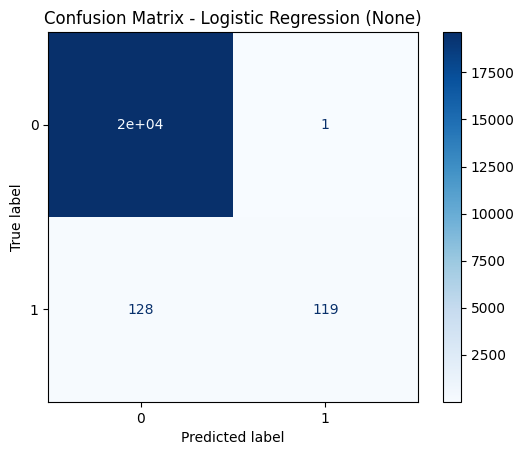

/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

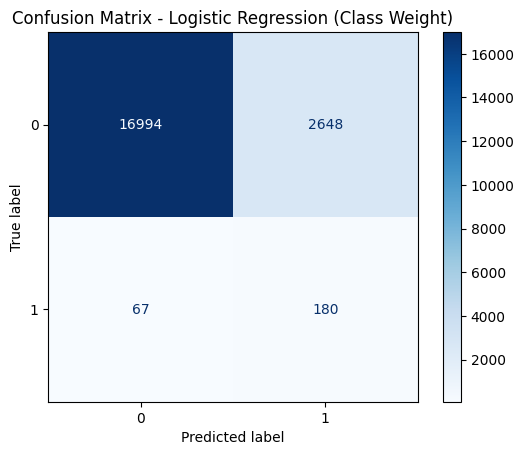

/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kingshukbarua/D

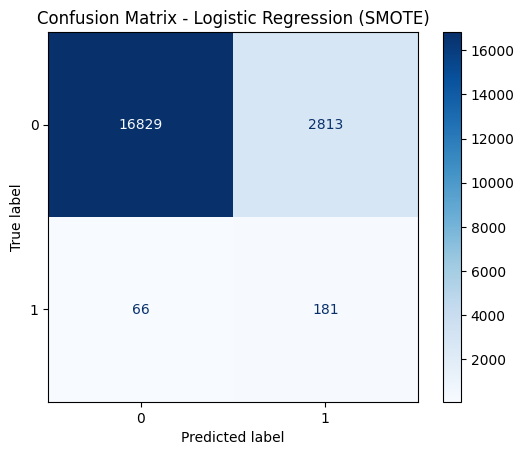

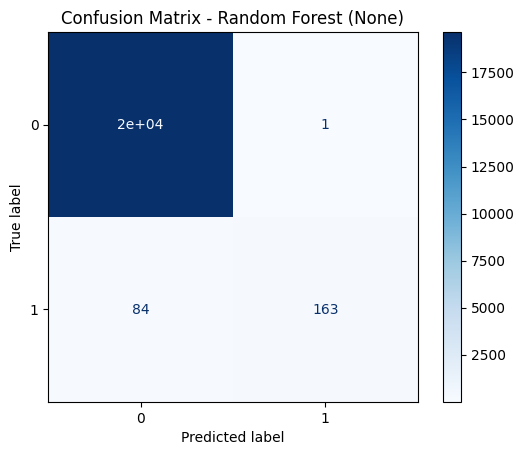

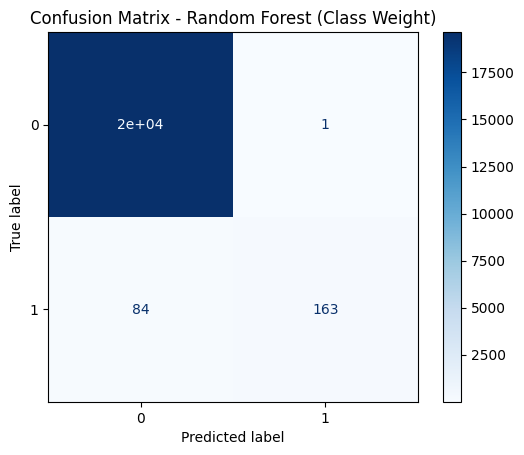

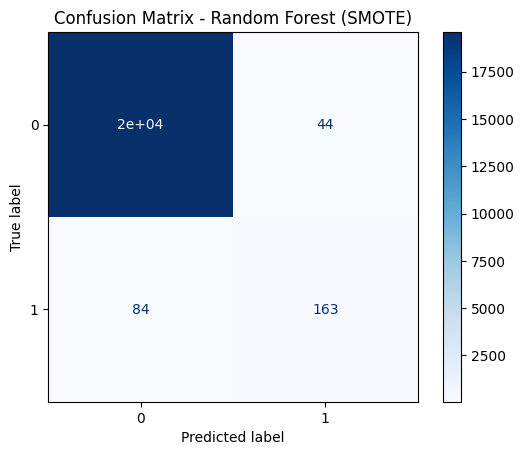


Comparison Table:


,Model,Method,Precision,Recall,F1-score,ROC-AUC
2,Logistic Regression,SMOTE,0.060454,0.732794,0.111694,0.846150
1,Logistic Regression,Class Weight,0.063649,0.728745,0.117073,0.861446
3,Random Forest,None,0.993902,0.659919,0.793187,0.877355
4,Random Forest,Class Weight,0.993902,0.659919,0.793187,0.861997
5,Random Forest,SMOTE,0.787440,0.659919,0.718062,0.835717
0,Logistic Regression,None,0.991667,0.481781,0.648501,0.861265



Final Recommendation
Best model: Random Forest
Best imbalance method: None
Trade-off: Recall=0.660, Precision=0.994, F1=0.793, ROC-AUC=0.877.
This option captures more cancellations (higher recall) while keeping precision at a practical level.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb


RANDOM_STATE = 42
INPUT_FILE = "final_model_dataset.csv"


def evaluate_predictions(y_true, y_pred, y_prob):
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }


def train_and_evaluate(model_name, method_name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    metrics = evaluate_predictions(y_test, y_pred, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name} ({method_name})")
    plt.show()

    return {
        "Model": model_name,
        "Method": method_name,
        **metrics,
    }


def main():
    df = pd.read_csv(INPUT_FILE)

    X = df.drop(columns=["cancel_flag"])
    y = df["cancel_flag"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    results = []

    # Logistic Regression approaches
    lr_none = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    )
    results.append(
        train_and_evaluate(
            "Logistic Regression",
            "None",
            lr_none,
            X_train,
            y_train,
            X_test,
            y_test,
        )
    )

    lr_weighted = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    results.append(
        train_and_evaluate(
            "Logistic Regression",
            "Class Weight",
            lr_weighted,
            X_train,
            y_train,
            X_test,
            y_test,
        )
    )

    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    lr_smote = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    )
    results.append(
        train_and_evaluate(
            "Logistic Regression",
            "SMOTE",
            lr_smote,
            X_train_smote,
            y_train_smote,
            X_test,
            y_test,
        )
    )

    # Random Forest approaches
    rf_none = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
    results.append(
        train_and_evaluate(
            "Random Forest",
            "None",
            rf_none,
            X_train,
            y_train,
            X_test,
            y_test,
        )
    )

    rf_weighted = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=300,
        class_weight="balanced",
    )
    results.append(
        train_and_evaluate(
            "Random Forest",
            "Class Weight",
            rf_weighted,
            X_train,
            y_train,
            X_test,
            y_test,
        )
    )

    rf_smote = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
    results.append(
        train_and_evaluate(
            "Random Forest",
            "SMOTE",
            rf_smote,
            X_train_smote,
            y_train_smote,
            X_test,
            y_test,
        )
    )

    results_df = pd.DataFrame(results).sort_values(
        by=["Recall", "Precision"], ascending=[False, False]
    )

    print("\nComparison Table:")
    display(results_df)

    precision_floor = 0.10
    candidates = results_df[results_df["Precision"] >= precision_floor]
    if candidates.empty:
        best_row = results_df.iloc[0]
    else:
        best_row = candidates.sort_values(
            by=["Recall", "Precision", "F1-score"], ascending=[False, False, False]
        ).iloc[0]

    print("\nFinal Recommendation")
    print(f"Best model: {best_row['Model']}")
    print(f"Best imbalance method: {best_row['Method']}")
    print(
        f"Trade-off: Recall={best_row['Recall']:.3f}, Precision={best_row['Precision']:.3f}, "
        f"F1={best_row['F1-score']:.3f}, ROC-AUC={best_row['ROC-AUC']:.3f}."
    )
    print(
        "This option captures more cancellations (higher recall) while keeping precision at a practical level."
    )


if __name__ == "__main__":
    main()

# RANDOM FOREST

In [8]:
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
INPUT_FILE = "final_model_dataset.csv"


def main() -> None:
    df = pd.read_csv(INPUT_FILE)

    X = df.drop(columns=["cancel_flag"])
    y = df["cancel_flag"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    best_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    best_model.fit(X_train, y_train)

    cancel_score = best_model.predict_proba(X_test)[:, 1]
    test_scores = pd.DataFrame(
        {
            "cancel_score": cancel_score,
            "cancel_flag": y_test.values,
            "actual_class": y_test.map({0: "Not Canceled", 1: "Canceled"}).values,
        }
    )

    auc = roc_auc_score(y_test, cancel_score)
    print(f"Random Forest (Class Weight) ROC-AUC: {auc:.4f}")

    fig = px.histogram(
        test_scores,
        x="cancel_score",
        color="actual_class",
        nbins=50,
        histnorm="percent",
        barmode="overlay",
        opacity=0.65,
        title="Distribution of Cancellation Score (Random Forest + Class Weight)",
        labels={
            "cancel_score": "Cancellation Score (Predicted Probability)",
            "actual_class": "Actual Class",
            "value": "Percentage",
        },
    )
    fig.update_layout(yaxis_title="Percentage of Test Samples")
    fig.show()


if __name__ == "__main__":
    main()

Random Forest (Class Weight) ROC-AUC: 0.8620


# XGBOOST WITH OPTUNA

/Users/kingshukbarua/Documents/SCA Project/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-16 12:42:06,250] A new study created in memory with name: no-name-f2862b33-6f62-4bac-a91c-6326b9cbf5f7
[I 2026-04-16 12:42:08,039] Trial 0 finished with value: 0.7601246105919003 and parameters: {'pos_weight_multiplier': 1.0634370982659669, 'n_estimators': 613, 'max_depth': 9, 'learning_rate': 0.08019834869555754, 'subsample': 0.7386742274297389, 'colsample_bytree': 0.9491503236343407, 'min_child_weight': 8, 'gamma': 3.088065730599869, 'reg_alpha': 0.001986666022557633, 'reg_lambda': 3.2595576680483388e-06}. Best is trial 0 with value: 0.7601246105919003.
[I 2026-04-16 12:42:09,029] Trial 1 finished with value: 0.7625 and parameters: {'pos_weight_multiplier': 0.6929120902558108, 'n_estimators': 363

Best Optuna score (validation F1): 0.7625
Selected validation threshold: 0.7300
Validation F1 at selected threshold: 0.7625
Validation precision at selected threshold: 0.9919
Validation recall at selected threshold: 0.6193
Best parameters:
{'n_estimators': 363, 'max_depth': 8, 'learning_rate': 0.16787355392558628, 'subsample': 0.7746681091096915, 'colsample_bytree': 0.6431746159099235, 'min_child_weight': 8, 'gamma': 4.238701298607251, 'reg_alpha': 0.006210759188846781, 'reg_lambda': 1.913868857032895e-05, 'scale_pos_weight': np.float64(55.12685795527591), 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}
Final Evaluation Metrics (Test Set)
Precision: 0.9588
Recall:    0.6599
F1-score:  0.7818
ROC-AUC:   0.8682


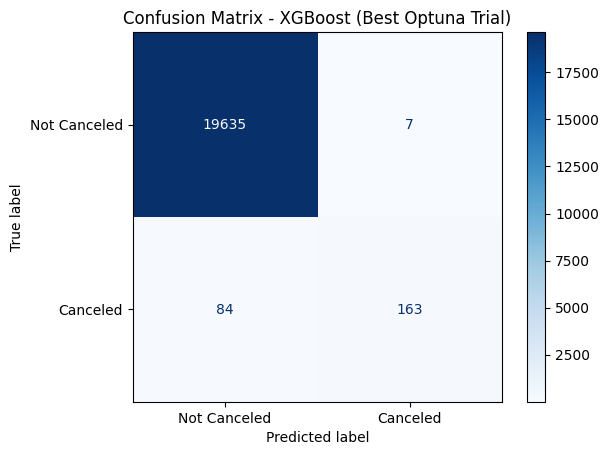

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    )
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
INPUT_FILE = "final_model_dataset.csv"
N_TRIALS = 50


def main() -> None:
    df = pd.read_csv(INPUT_FILE)

    X = df.drop(columns=["cancel_flag"])

    y = df["cancel_flag"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

    base_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    def objective(trial: optuna.Trial) -> float:
        pos_weight_multiplier = trial.suggest_float("pos_weight_multiplier", 0.5, 2.0)

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "scale_pos_weight": base_pos_weight * pos_weight_multiplier,
            "objective": "binary:logistic",
            "eval_metric": "aucpr",
            "tree_method": "hist",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        threshold_grid = np.linspace(0.05, 0.95, 91)
        f1_scores = [
            f1_score(y_val, (val_prob >= t).astype(int), zero_division=0)
            for t in threshold_grid
        ]

        best_idx = int(np.argmax(f1_scores))
        best_threshold = float(threshold_grid[best_idx])
        best_f1 = float(f1_scores[best_idx])

        best_pred = (val_prob >= best_threshold).astype(int)
        best_precision = float(precision_score(y_val, best_pred, zero_division=0))
        best_recall = float(recall_score(y_val, best_pred, zero_division=0))

        trial.set_user_attr("best_threshold", best_threshold)
        trial.set_user_attr("best_f1", best_f1)
        trial.set_user_attr("best_precision", best_precision)
        trial.set_user_attr("best_recall", best_recall)

        return best_f1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_multiplier = best_params.pop("pos_weight_multiplier")
    best_params["scale_pos_weight"] = base_pos_weight * best_multiplier
    best_params.update(
        {
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "tree_method": "hist",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
    )

    best_threshold = float(study.best_trial.user_attrs.get("best_threshold", 0.5))
    val_f1_at_best = float(study.best_trial.user_attrs.get("best_f1", 0.0))
    val_precision_at_best = float(study.best_trial.user_attrs.get("best_precision", 0.0))
    val_recall_at_best = float(study.best_trial.user_attrs.get("best_recall", 0.0))

    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_train, y_train)

    y_prob = final_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Best Optuna score (validation F1):", f"{study.best_value:.4f}")
    print(f"Selected validation threshold: {best_threshold:.4f}")
    print(f"Validation F1 at selected threshold: {val_f1_at_best:.4f}")
    print(f"Validation precision at selected threshold: {val_precision_at_best:.4f}")
    print(f"Validation recall at selected threshold: {val_recall_at_best:.4f}")
    print("Best parameters:")
    print(best_params)

    print("Final Evaluation Metrics (Test Set)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Not Canceled", "Canceled"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix - XGBoost (Best Optuna Trial)")
    plt.show()

    score_df = pd.DataFrame(
        {
            "cancel_score": y_prob,
            "actual_class": y_test.map({0: "Not Canceled", 1: "Canceled"}).values,
        }
    )

    fig = px.histogram(
        score_df,
        x="cancel_score",
        color="actual_class",
        nbins=50,
        histnorm="percent",
        barmode="overlay",
        opacity=0.65,
        title="Predicted Cancellation Score Distribution (XGBoost + Optuna)",
        labels={
            "cancel_score": "Predicted Cancellation Score",
            "actual_class": "Actual Class",
            "value": "Percentage",
        },
    )
    fig.update_layout(yaxis_title="Percentage of Test Samples")
    fig.show()


if __name__ == "__main__":
    main()